# Clean Data

In [3]:
#Cleaning Data
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('GlobalWeatherRepository.csv', on_bad_lines='skip')

# We only focus on thailand
df = df[df['location_name'] == 'Bangkok']
# Drop redundant data
# Using Celsius, km/h, mm
# Drop Fahrenheit, mph, inches and epoch time
cols_to_drop = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph',
    'last_updated_epoch',
    'country',
    'location_name',
    'timezone',
    'latitude',
    'longitude',
    'wind_degree',
    'wind_direction'
]
df = df.drop(columns=cols_to_drop)
# Drop complex time columns
complex_time_cols = ['sunrise', 'sunset', 'moonrise', 'moonset']
df = df.drop(columns=complex_time_cols)

# Datetime Features
# -------------------------
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
df = df.drop(columns=['last_updated'])

def simplify_condition(text):
    text = str(text).lower()

    if 'thunder' in text or 'storm' in text:
        return 'Thunder'
    elif 'drizzle' in text:
        return 'Drizzle'
    elif 'rain' in text:
        return 'Rain'
    elif 'cloud' in text or 'overcast' in text:
        return 'Cloudy'
    elif 'sunny' in text or 'clear' in text:
        return 'Clear'
    else:
        return 'Other'

df['condition_text'] = df['condition_text'].apply(simplify_condition)

print(df['condition_text'].unique())

# Save
df.to_csv('Cleaned_Weather_Data.csv', index=False)

['Cloudy' 'Thunder' 'Rain' 'Clear' 'Drizzle']


In [4]:
#Label mapping
import json
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('Cleaned_Weather_Data.csv', on_bad_lines='skip')

# 2. Define categorical columns to encode
categorical_cols = ['condition_text', 'moon_phase']

# Dictionary to store the mapping for each column
label_mappings = {}

# 3. Process each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the data
    df[col] = le.fit_transform(df[col].astype(str))

    # Extract the mapping (index to class label)
    mapping = {int(index): label for index, label in enumerate(le.classes_)}

    # Store it in the main dictionary
    label_mappings[col] = mapping

# 4. Save the mappings to a JSON file
with open('label_mappings.json', 'w', encoding='utf-8') as file:
    json.dump(label_mappings, file, ensure_ascii=False, indent=4)

print("Dictionary saved successfully as 'label_mappings.json'")

Dictionary saved successfully as 'label_mappings.json'


In [5]:
#----------------------------
# EDA Setup (รันอันนี้ก่อน ไม่งั้นรันEDAกับFeatureไม่ได้)
#----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bangkok_df = pd.read_csv('Cleaned_Weather_Data.csv')

bangkok_df.info()
bangkok_df.describe()
bangkok_df.isnull().sum()

sns.set_style("whitegrid")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature_celsius           701 non-null    float64
 1   condition_text                701 non-null    object 
 2   wind_kph                      701 non-null    float64
 3   pressure_mb                   701 non-null    float64
 4   precip_mm                     701 non-null    float64
 5   humidity                      701 non-null    int64  
 6   cloud                         701 non-null    int64  
 7   feels_like_celsius            701 non-null    float64
 8   visibility_km                 701 non-null    float64
 9   uv_index                      701 non-null    float64
 10  gust_kph                      701 non-null    float64
 11  air_quality_Carbon_Monoxide   701 non-null    float64
 12  air_quality_Ozone             701 non-null    float64
 13  air_q

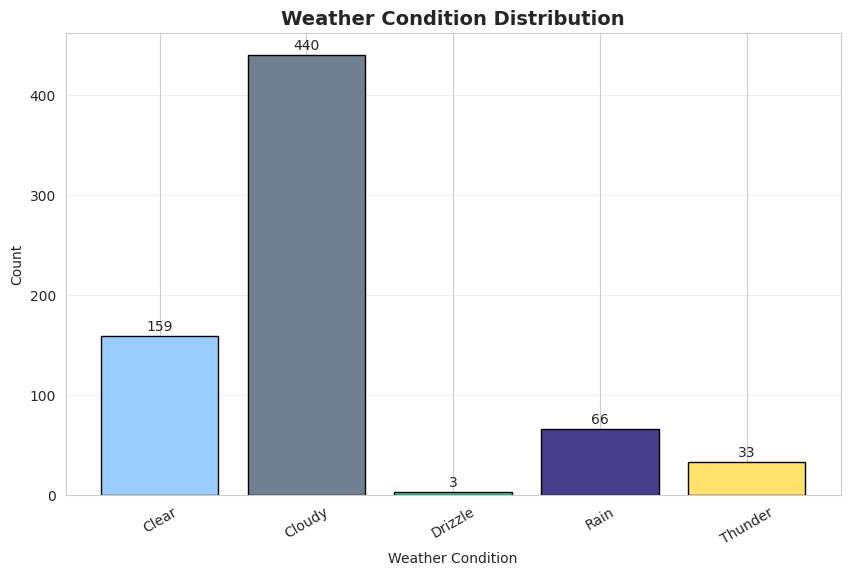

In [6]:
# Weather Con Distribution (Weather Classification)
cond_count = df['condition_text'].value_counts().sort_index()
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)

condition_map = mappings['condition_text']
cond_count.index = cond_count.index.map(lambda x: condition_map[str(x)])

plt.figure(figsize=(10,6))
bars = plt.bar(cond_count.index, cond_count.values,
               color=['#99CCFF','#708090','#33CC99','#483D8B','#ffe16d','#FF3399'],
               edgecolor='black')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5,
             f'{int(y):,}', ha='center', fontsize=10)

plt.title("Weather Condition Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.show()

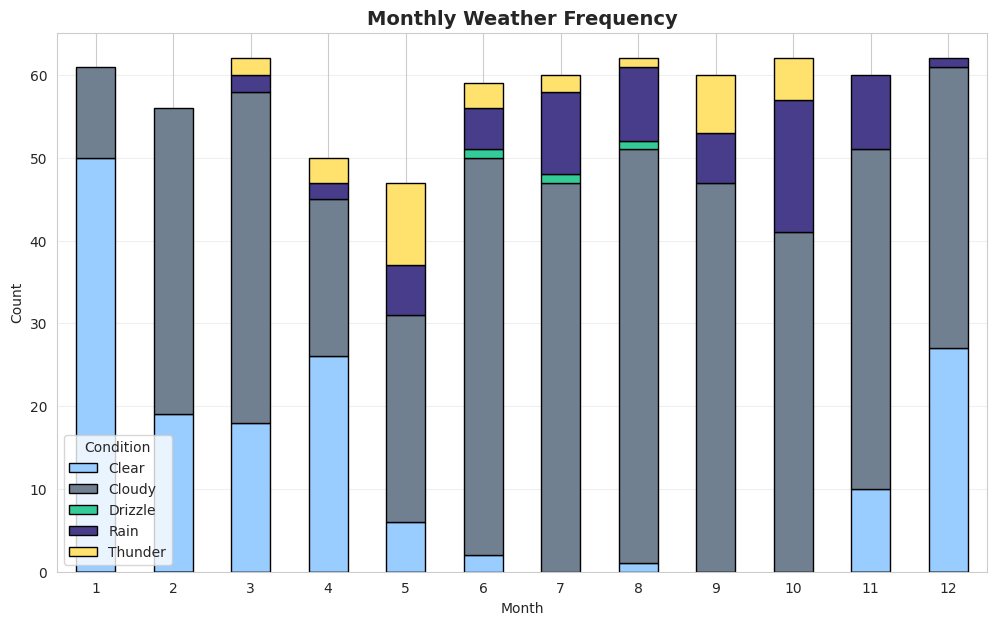

In [7]:
# Monthly Weather Freq (Weather Classification)
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)
condition_map = mappings['condition_text']

df['condition_name'] = df['condition_text'].map(lambda x: condition_map[str(x)])

monthly_weather = df.groupby(['month', 'condition_name']).size().unstack(fill_value=0)
monthly_weather.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#99CCFF','#708090','#33CC99','#483D8B','#ffe16d','#FF3399'],
    edgecolor='black'
)

plt.title("Monthly Weather Frequency", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.grid(axis='y', alpha=0.3)
plt.show()

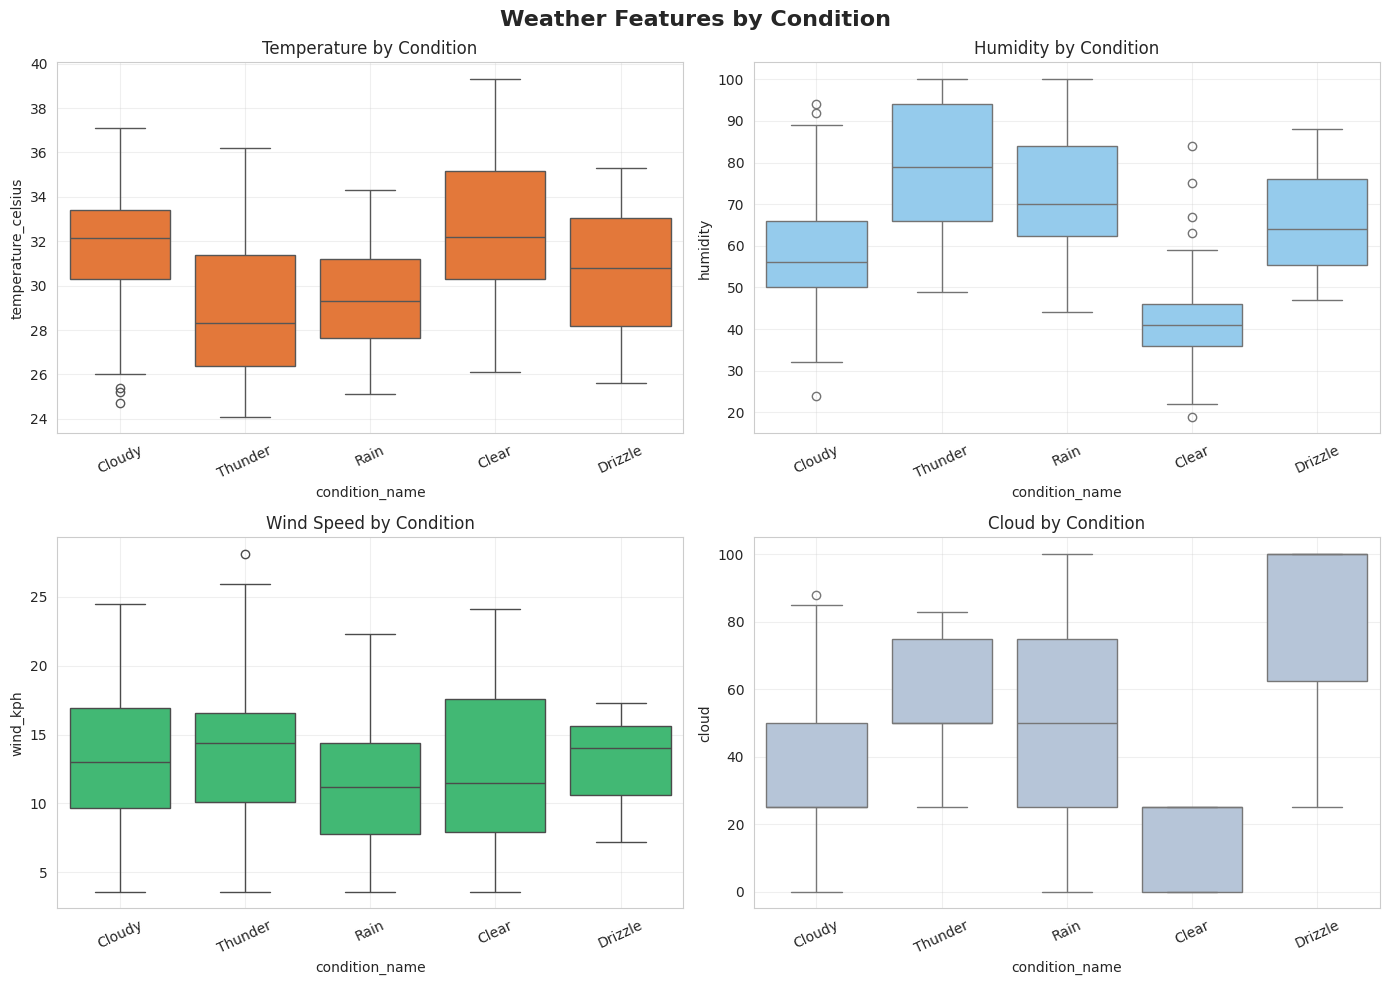

In [8]:
# Weather Features by Con (Weather Classification)
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)
condition_map = mappings['condition_text']

df['condition_name'] = df['condition_text'].map(lambda x: condition_map[str(x)])
plot_df = df[['condition_name', 'temperature_celsius', 'humidity', 'wind_kph', 'cloud']]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Weather Features by Condition", fontsize=16, fontweight='bold')

# Temp
sns.boxplot(data=plot_df, x='condition_name', y='temperature_celsius',
            ax=axes[0,0], color='#ff701e')
axes[0,0].set_title("Temperature by Condition")

# Humidity
sns.boxplot(data=plot_df, x='condition_name', y='humidity',
            ax=axes[0,1], color='#87CEFA')
axes[0,1].set_title("Humidity by Condition")

# Wind
sns.boxplot(data=plot_df, x='condition_name', y='wind_kph',
            ax=axes[1,0], color='#2ecc71')
axes[1,0].set_title("Wind Speed by Condition")

# Cloud
sns.boxplot(data=plot_df, x='condition_name', y='cloud',
            ax=axes[1,1], color='#B0C4DE')
axes[1,1].set_title("Cloud by Condition")

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

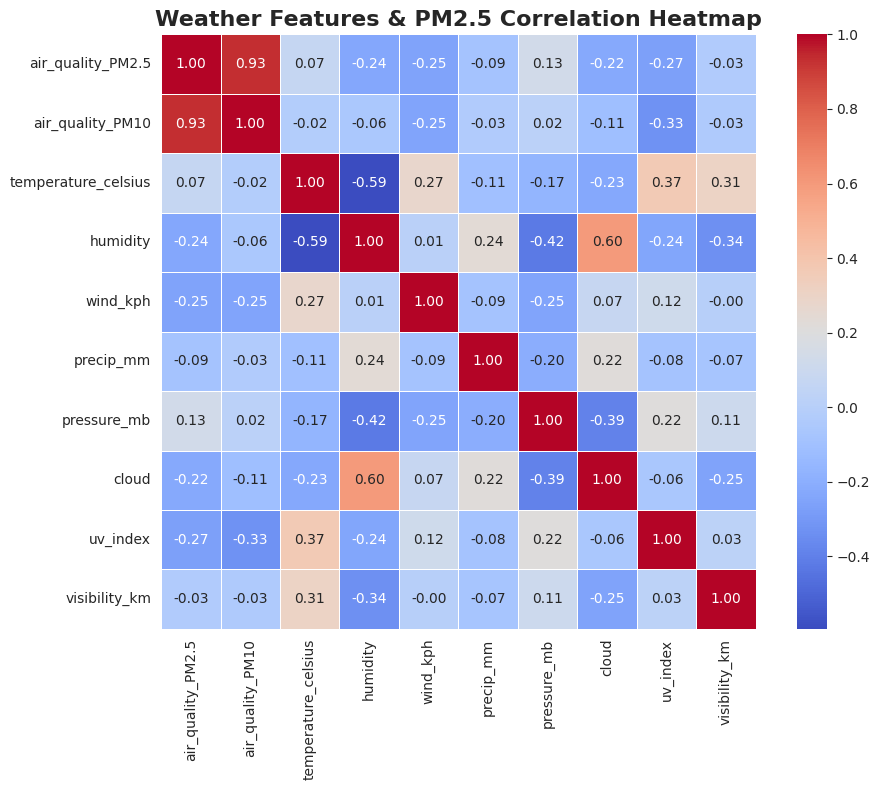

In [9]:
# Correlation Heatmap (PM2.5 Prediction)
cols = [
    'air_quality_PM2.5',
    'air_quality_PM10',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'pressure_mb',
    'cloud',
    'uv_index',
    'visibility_km',
]
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkokhm_df = bangkok_df[cols]
corr = bangkokhm_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Weather Features & PM2.5 Correlation Heatmap",fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

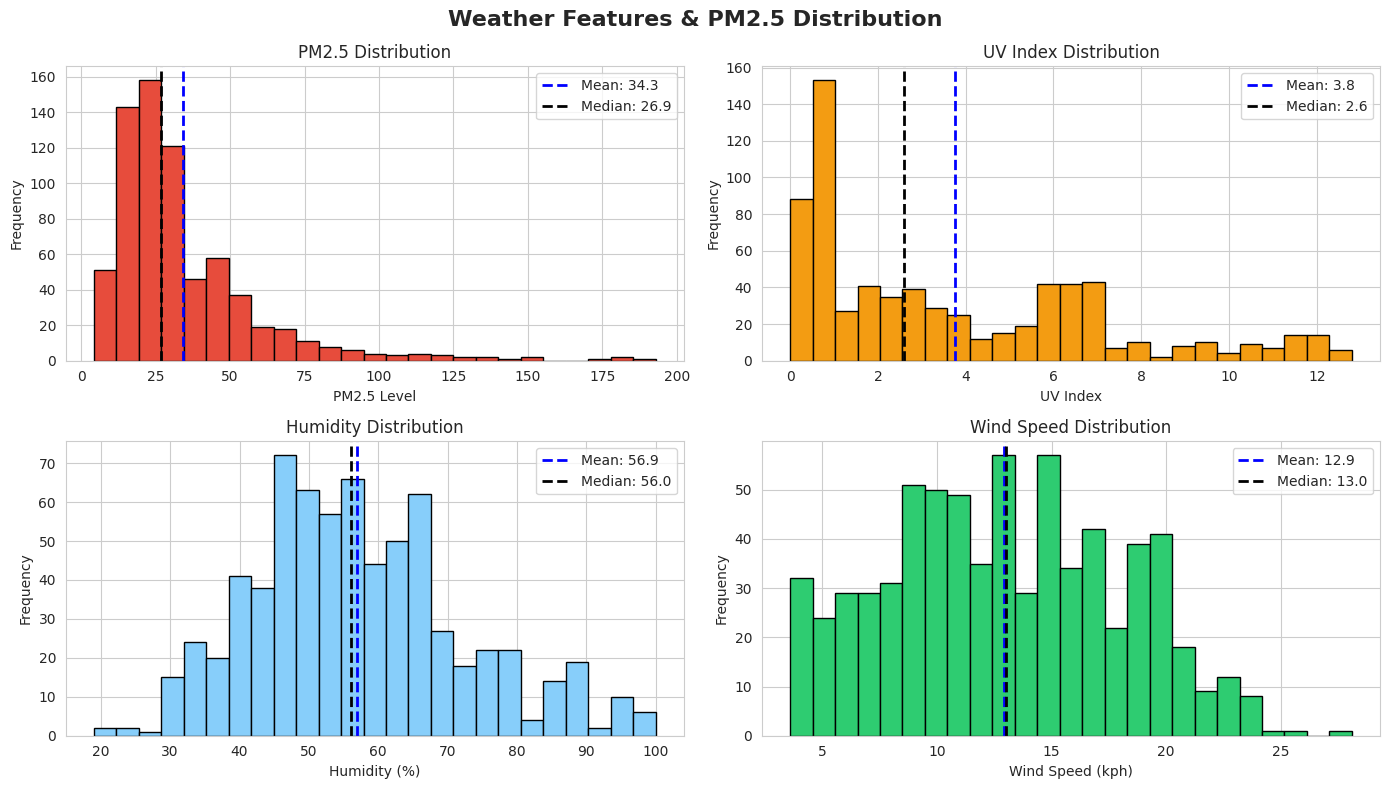

In [10]:
# Distribution (PM2.5 Prediction)
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Weather Features & PM2.5 Distribution", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'humidity', 'wind_kph']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

# PM2.5
mean_pm = bangkok_df['air_quality_PM2.5'].mean()
median_pm = bangkok_df['air_quality_PM2.5'].median()

axes[0,0].hist(bangkok_df['air_quality_PM2.5'], bins=25, color='#e74c3c', edgecolor='black')
axes[0,0].axvline(mean_pm, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_pm:.1f}')
axes[0,0].axvline(median_pm, color='black', linestyle='--', linewidth=2, label=f'Median: {median_pm:.1f}')
axes[0,0].set_title("PM2.5 Distribution")
axes[0,0].set_xlabel("PM2.5 Level")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# UV
mean_uv = bangkok_df['uv_index'].mean()
median_uv = bangkok_df['uv_index'].median()

axes[0,1].hist(bangkok_df['uv_index'], bins=25, color='#f39c12', edgecolor='black')
axes[0,1].axvline(mean_uv, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_uv:.1f}')
axes[0,1].axvline(median_uv, color='black', linestyle='--', linewidth=2, label=f'Median: {median_uv:.1f}')
axes[0,1].set_title("UV Index Distribution")
axes[0,1].set_xlabel("UV Index")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# Humidity
mean_h = bangkok_df['humidity'].mean()
median_h = bangkok_df['humidity'].median()

axes[1,0].hist(bangkok_df['humidity'], bins=25, color='#87CEFA', edgecolor='black')
axes[1,0].axvline(mean_h, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_h:.1f}')
axes[1,0].axvline(median_h, color='black', linestyle='--', linewidth=2, label=f'Median: {median_h:.1f}')
axes[1,0].set_title("Humidity Distribution")
axes[1,0].set_xlabel("Humidity (%)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend()

# Wind Speed
mean_w = bangkok_df['wind_kph'].mean()
median_w = bangkok_df['wind_kph'].median()

axes[1,1].hist(bangkok_df['wind_kph'], bins=25, color='#2ecc71', edgecolor='black')
axes[1,1].axvline(mean_w, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_w:.1f}')
axes[1,1].axvline(median_w, color='black', linestyle='--', linewidth=2, label=f'Median: {median_w:.1f}')
axes[1,1].set_title("Wind Speed Distribution")
axes[1,1].set_xlabel("Wind Speed (kph)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()

plt.tight_layout()
plt.show()

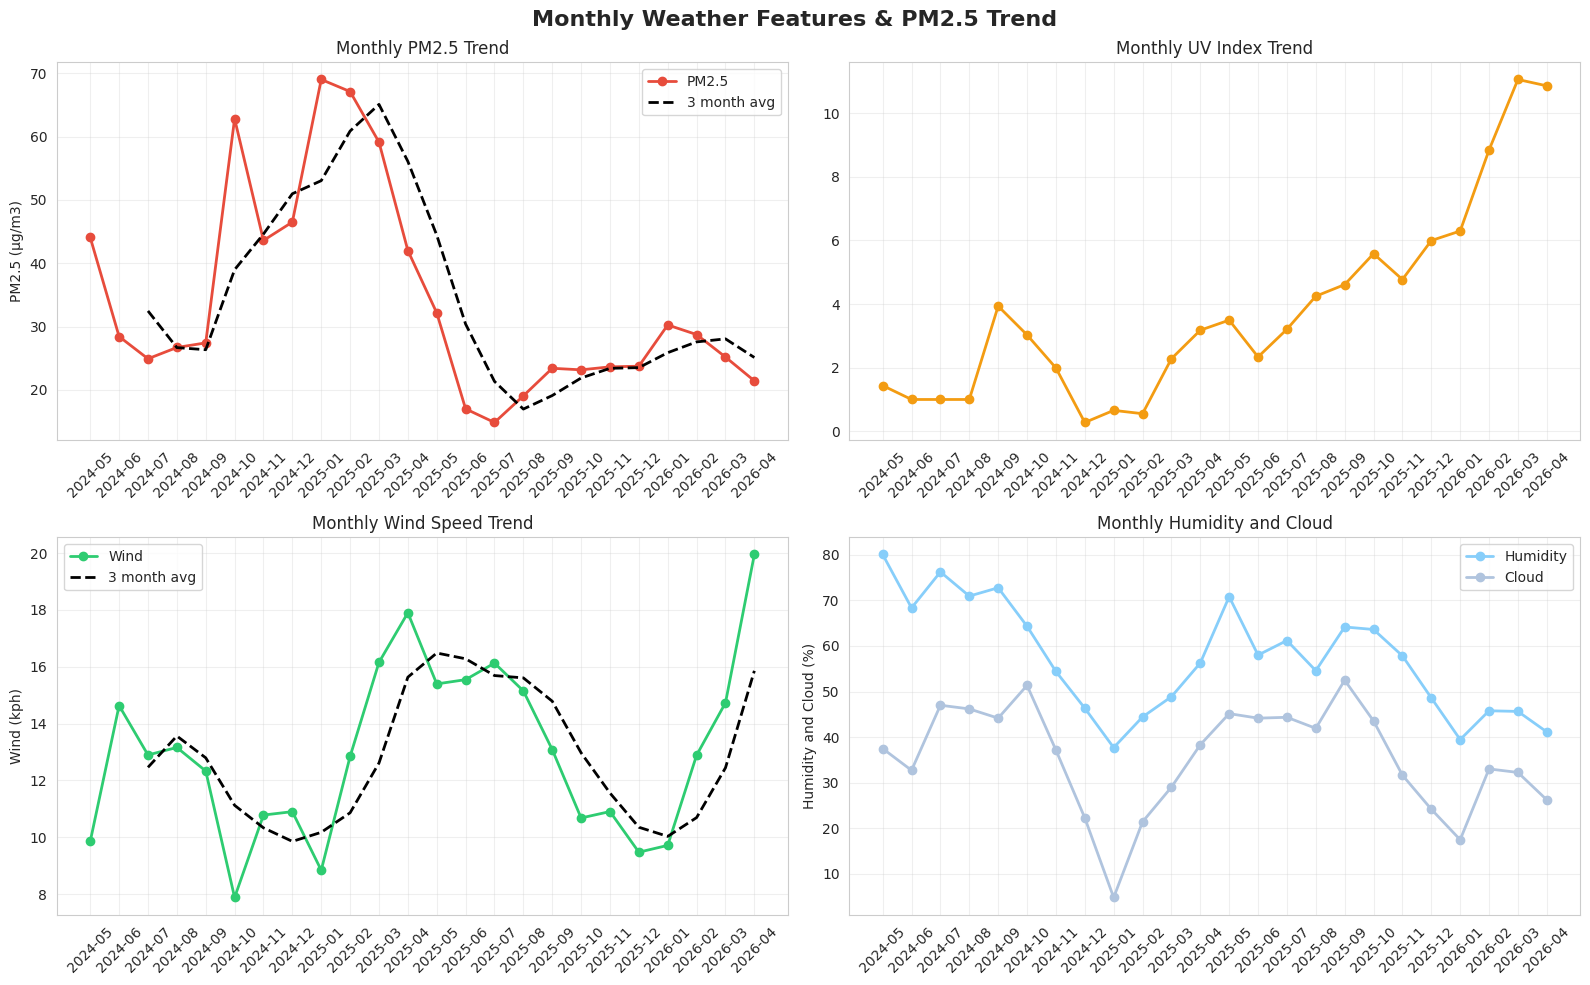

In [11]:
# Monthly Trend (PM2.5 Prediction)
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Monthly Weather Features & PM2.5 Trend", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'wind_kph', 'humidity', 'cloud']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df['year_month'] = (
    bangkok_df['year'].astype(int).astype(str) + '-' +
    bangkok_df['month'].astype(int).astype(str).str.zfill(2)
)
# monthly avg
monthly = bangkok_df.groupby('year_month')[cols].mean().reset_index()

# 3 month avg
monthly['pm_mavg3'] = monthly['air_quality_PM2.5'].rolling(3).mean()
monthly['wind_mavg3'] = monthly['wind_kph'].rolling(3).mean()

# PM2.5
axes[0,0].plot(monthly['year_month'], monthly['air_quality_PM2.5'],
               color='#e74c3c', marker='o', linewidth=2, label='PM2.5')
axes[0,0].plot(monthly['year_month'], monthly['pm_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[0,0].set_title("Monthly PM2.5 Trend")
axes[0,0].set_ylabel("PM2.5 (µg/m3)")
axes[0,0].legend()

# UV Index
axes[0,1].plot(monthly['year_month'], monthly['uv_index'],
               color='#f39c12', marker='o', linewidth=2)
axes[0,1].set_title("Monthly UV Index Trend")

# Wind
axes[1,0].plot(monthly['year_month'], monthly['wind_kph'],
               color='#2ecc71', marker='o', linewidth=2, label='Wind')
axes[1,0].plot(monthly['year_month'], monthly['wind_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[1,0].set_title("Monthly Wind Speed Trend")
axes[1,0].set_ylabel("Wind (kph)")
axes[1,0].legend()

# Humidity and Cloud
ax1 = axes[1,1]
ax2 = axes[1,1]

ax1.plot(monthly['year_month'], monthly['humidity'],
         color='#87CEFA', marker='o', linewidth=2, label='Humidity')

ax2.plot(monthly['year_month'], monthly['cloud'],
         color='#B0C4DE', marker='o', linewidth=2, label='Cloud')

ax1.set_title("Monthly Humidity and Cloud")
ax1.set_ylabel("Humidity and Cloud (%)")
ax1.legend()

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

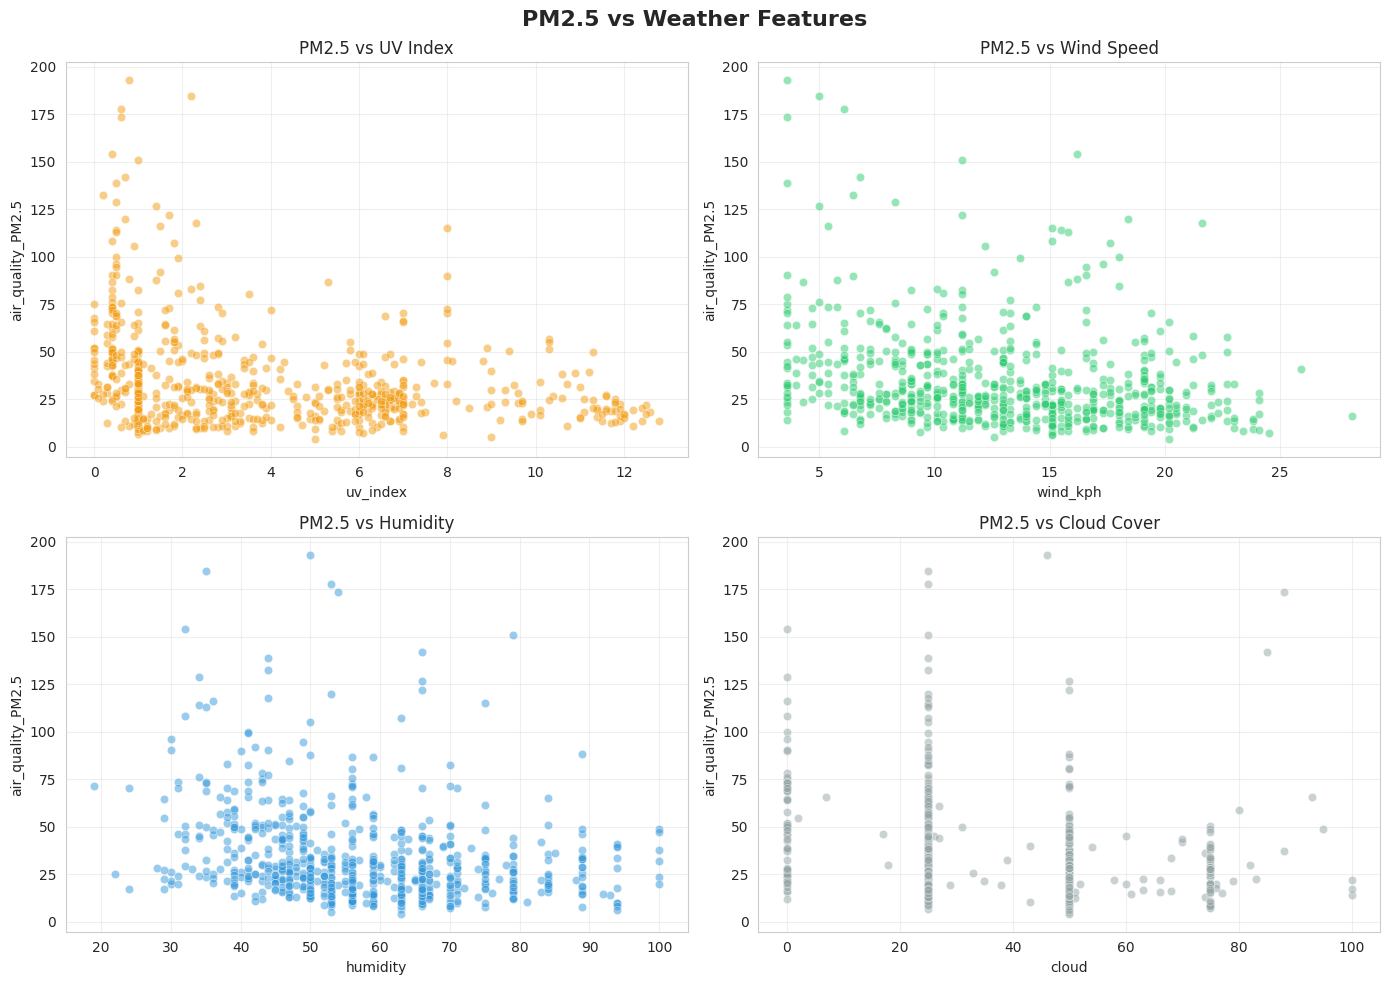

In [12]:
# PM2.5 Relationship (PM2.5 Prediction)
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("PM2.5 vs Weather Features", fontsize=16, fontweight='bold')

# PM2.5 vs UV
sns.scatterplot(data=df, x='uv_index', y='air_quality_PM2.5',
                ax=axes[0,0], color='#f39c12', alpha=0.5)
axes[0,0].set_title("PM2.5 vs UV Index")

# PM2.5 vs Wind
sns.scatterplot(data=df, x='wind_kph', y='air_quality_PM2.5',
                ax=axes[0,1], color='#2ecc71', alpha=0.5)
axes[0,1].set_title("PM2.5 vs Wind Speed")

# PM2.5 vs Humidity
sns.scatterplot(data=df, x='humidity', y='air_quality_PM2.5',
                ax=axes[1,0], color='#3498db', alpha=0.5)
axes[1,0].set_title("PM2.5 vs Humidity")

# PM2.5 vs Cloud
sns.scatterplot(data=df, x='cloud', y='air_quality_PM2.5',
                ax=axes[1,1], color='#95a5a6', alpha=0.5)
axes[1,1].set_title("PM2.5 vs Cloud Cover")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
#----------------------------
# Feature Engineering
#----------------------------

# Season from month
def get_season(month):
    if month in [11, 12, 1, 2]:
        return "Cool"
    elif month in [3, 4, 5]:
        return "Hot"
    else:
        return "Rainy"

bangkok_df['season'] = bangkok_df['month'].apply(get_season)

bangkok_df[['month', 'season']].sample(10)

,month,season
131,9,Rainy
348,5,Hot
635,2,Cool
557,11,Cool
325,4,Hot
402,6,Rainy
145,10,Rainy
223,12,Cool
494,9,Rainy
478,9,Rainy


In [14]:
# Lag 1 day
bangkok_df['pm_lag'] = bangkok_df['air_quality_PM2.5'].shift(1)
bangkok_df['wind_lag'] = bangkok_df['wind_kph'].shift(1)
bangkok_df['uv_lag'] = bangkok_df['uv_index'].shift(1)
bangkok_df['humidity_lag'] = bangkok_df['humidity'].shift(1)
bangkok_df['cloud_lag'] = bangkok_df['cloud'].shift(1)

bangkok_df[['air_quality_PM2.5','pm_lag',
            'wind_kph','wind_lag',
            'uv_index','uv_lag',
            'humidity','humidity_lag',
            'cloud','cloud_lag']].head(10)

,air_quality_PM2.5,pm_lag,wind_kph,wind_lag,uv_index,uv_lag,humidity,humidity_lag,cloud,cloud_lag
0,115.2,NaN,15.1,NaN,8.0,NaN,75,NaN,25,NaN
1,150.8,115.2,11.2,15.1,1.0,8.0,79,75.0,25,25.0
2,33.2,150.8,9.0,11.2,1.0,1.0,75,79.0,25,25.0
3,14.8,33.2,9.0,9.0,1.0,1.0,89,75.0,50,25.0
4,65.0,14.8,6.1,9.0,1.0,1.0,84,89.0,25,50.0
5,25.9,65.0,3.6,6.1,1.0,1.0,89,84.0,25,25.0
6,26.1,25.9,9.0,3.6,1.0,1.0,75,89.0,50,25.0
7,28.5,26.1,6.8,9.0,1.0,1.0,94,75.0,50,50.0
8,31.7,28.5,13.0,6.8,1.0,1.0,75,94.0,25,50.0
9,18.3,31.7,6.1,13.0,1.0,1.0,79,75.0,25,25.0


In [15]:
# Interaction
bangkok_df['Humidity_over_Cloud'] = bangkok_df['humidity'] / bangkok_df['cloud']
bangkok_df['Humidity_over_Temp'] = bangkok_df['humidity'] / bangkok_df['temperature_celsius']
bangkok_df['Humidity_over_Visibility'] = bangkok_df['humidity'] / bangkok_df['visibility_km']
bangkok_df['Gust_over_Wind'] = bangkok_df['gust_kph'] / bangkok_df['wind_kph']
bangkok_df[[ 'temperature_celsius',
           'humidity',
           'visibility_km',
           'cloud',
           'gust_kph',
           'wind_kph',
           'Humidity_over_Cloud',
           'Humidity_over_Temp',
           'Humidity_over_Visibility',
           'Gust_over_Wind']].head(10)

,temperature_celsius,humidity,visibility_km,cloud,gust_kph,wind_kph,Humidity_over_Cloud,Humidity_over_Temp,Humidity_over_Visibility,Gust_over_Wind
0,31.0,75,10.0,25,18.2,15.1,3.00,2.419355,7.500000,1.205298
1,30.0,79,10.0,25,20.9,11.2,3.16,2.633333,7.900000,1.866071
2,31.0,75,10.0,25,24.1,9.0,3.00,2.419355,7.500000,2.677778
3,27.0,89,9.0,50,23.2,9.0,1.78,3.296296,9.888889,2.577778
4,30.0,84,10.0,25,24.8,6.1,3.36,2.800000,8.400000,4.065574
5,27.0,89,10.0,25,37.5,3.6,3.56,3.296296,8.900000,10.416667
6,30.0,75,10.0,50,17.0,9.0,1.50,2.500000,7.500000,1.888889
7,27.0,94,8.0,50,14.6,6.8,1.88,3.481481,11.750000,2.147059
8,30.0,75,10.0,25,20.2,13.0,3.00,2.500000,7.500000,1.553846
9,30.0,79,10.0,25,13.1,6.1,3.16,2.633333,7.900000,2.147541


In [16]:
# Day/Night
bangkok_df['is_day'] = bangkok_df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)
bangkok_df[['hour',
           'is_day']].sample(10)

,hour,is_day
657,13,1
560,14,1
133,16,1
22,21,0
489,15,1
620,14,1
643,13,1
403,16,1
599,14,1
619,14,1


Preparing Data and Feature Engineering

In [17]:
import numpy as np
import json
import pandas as pd

df = bangkok_df.copy()

# Load label mappings for categorical features
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    label_maps = json.load(f)

# Apply label encoding using the loaded mappings (string label to integer)
# The stored mappings are int_key: string_value, so we need to reverse them for transformation
condition_text_reverse_map = {v: int(k) for k, v in label_maps['condition_text'].items()}
many_missing_condition_text = df['condition_text'].map(condition_text_reverse_map).isna().sum()
if many_missing_condition_text > 0:
    print(f"Warning: {many_missing_condition_text} condition_text values not found in mapping. Filling with -1.")
df['condition_text'] = df['condition_text'].map(condition_text_reverse_map).fillna(-1) # Fill missing with -1 for robustness

moon_phase_reverse_map = {v: int(k) for k, v in label_maps['moon_phase'].items()}
many_missing_moon_phase = df['moon_phase'].map(moon_phase_reverse_map).isna().sum()
if many_missing_moon_phase > 0:
    print(f"Warning: {many_missing_moon_phase} moon_phase values not found in mapping. Filling with -1.")
df['moon_phase'] = df['moon_phase'].map(moon_phase_reverse_map).fillna(-1) # Fill missing with -1 for robustness

# One-hot encode 'season'
df = pd.get_dummies(df, columns=['season'], drop_first=True, dtype=int)

# Drop 'year_month' as it's an object type column created for plotting and not a feature.
if 'year_month' in df.columns:
    df = df.drop(columns=['year_month'])

df = df.sort_values(by=['year','month','day','hour'])

# Handle infinite and NaN values introduced during feature engineering or data loading
df = df.replace([np.inf, -np.inf], np.nan)
# Drop rows with any NaN values after encoding and sorting, before creating features
df = df.dropna()

# Lag features
df['pm_lag1'] = df['air_quality_PM2.5'].shift(1)
df['pm_lag2'] = df['air_quality_PM2.5'].shift(2)
df['pm_lag3'] = df['air_quality_PM2.5'].shift(3)
df['pm_lag6'] = df['air_quality_PM2.5'].shift(6)
df['pm_lag12'] = df['air_quality_PM2.5'].shift(12)
df['pm_lag24'] = df['air_quality_PM2.5'].shift(24)

# Rolling features
df['pm_roll3'] = df['air_quality_PM2.5'].shift(1).rolling(3).mean()
df['pm_roll6'] = df['air_quality_PM2.5'].shift(1).rolling(6).mean()
df['pm_roll9'] = df['air_quality_PM2.5'].shift(1).rolling(9).mean()
df['pm_roll12'] = df['air_quality_PM2.5'].shift(1).rolling(12).mean()
df['pm_roll24'] = df['air_quality_PM2.5'].shift(1).rolling(24).mean()

# Trend features
df['pm_diff1'] = df['air_quality_PM2.5'].shift(1).diff()

# Stability features
df['pm_std6'] = df['air_quality_PM2.5'].shift(1).rolling(6).std()

# Interaction features (adjusted to avoid division by zero)
df['Humidity_over_Cloud'] = df['humidity'] / (df['cloud'] + 1)
df['Gust_over_Wind'] = df['gust_kph'] / (df['wind_kph'] + 1)

# Day/Night feature
df['is_day'] = df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)

# Time feature
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# Drop rows with any NaN values after creating features
df = df.dropna()

Define Features

In [18]:
features = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'pressure_mb',
    'cloud',
    'uv_index',
    'visibility_km',

    # lag
    'pm_lag1', 'pm_lag2','pm_lag3', 'pm_lag6','pm_lag12','pm_lag24',

    # rolling
    'pm_roll3', 'pm_roll6','pm_roll9', 'pm_roll12','pm_roll24',

    # trend
    'pm_diff1',

    # stability
    'pm_std6',

    # interactions
    'Humidity_over_Cloud',
    'Gust_over_Wind',

    # time
    'hour', 'month', 'is_day','hour_sin','hour_cos','month_sin','month_cos',

    # season encoded columns will auto include
]

Split Data

In [19]:
# Ensure df is cleaned of NaNs from feature engineering, if not already handled
df = df.dropna()

split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

# Select only the defined features for X_train and X_test using the 'features' list
X_train = train[features]
y_train = train['air_quality_PM2.5']

X_test = test[features]
y_test = test['air_quality_PM2.5']

Baseline Model

In [20]:
import numpy as np

# baseline prediction = previous value
y_pred_baseline = X_test['pm_lag1']

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)
print("Baseline R2:", r2)

Baseline MAE: 8.653658536585366
Baseline RMSE: 12.38380794372199
Baseline R2: -0.22029035958819065


Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, min_samples_split=5, n_estimators=200,
                      random_state=42)

Gradient Regressor

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)
gb.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200)

XGBoost Regressor

In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

Comparing each Regressor's result

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

evaluate("Random Forest", y_test, rf.predict(X_test))
evaluate("Gradient Boost", y_test, gb.predict(X_test))
evaluate("XGBoost", y_test, xgb.predict(X_test))



Random Forest
MAE: 8.626818864789268
RMSE: 12.568137702625032
R2: -0.2568881305545727

Gradient Boost
MAE: 9.712753888684455
RMSE: 13.83473146808213
R2: -0.52298712529779

XGBoost
MAE: 8.216506592044984
RMSE: 11.815094865622283
R2: -0.11078291241196347


See which feature contribute the most to the prediction

In [25]:
import pandas as pd

importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

,0
pm_lag1,0.195341
pm_roll9,0.085230
pm_roll12,0.076443
pm_roll6,0.064283
wind_kph,0.056887
month_cos,0.051365
hour_cos,0.043221
pm_roll3,0.040494
pm_diff1,0.032222
pm_roll24,0.030511


Comparing Predicted Information with Actual Information

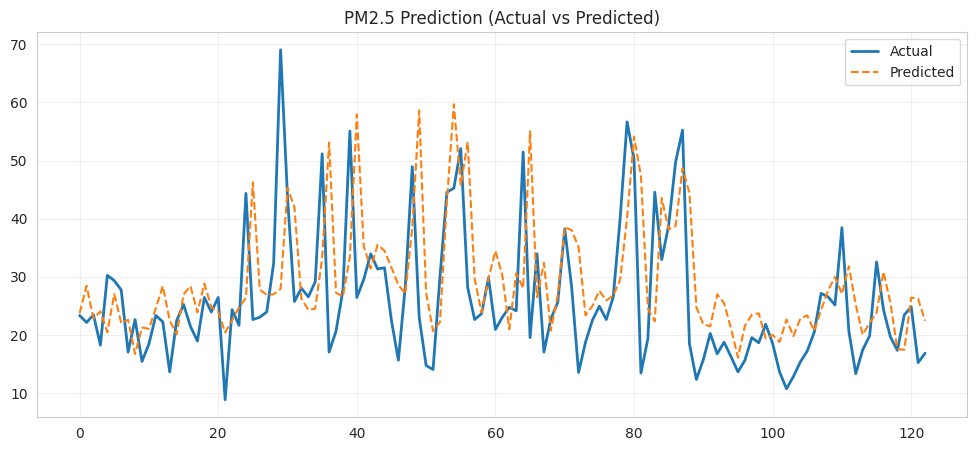

In [26]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(xgb.predict(X_test), label='Predicted', linestyle='--')
plt.legend()
plt.title("PM2.5 Prediction (Actual vs Predicted)")
plt.grid(alpha=0.3)
plt.show()

Hyperparameter Tuning with Optuna and TimeSeriesSplit

In [27]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.0 MB/s eta 0:00:00


In [37]:
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------
# 1. Clean + sort
# -------------------------------------------------
df = df.sort_values(['year','month','day','hour']).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

target = 'air_quality_PM2.5'

X = df.drop(columns=[target]).astype(float)
y = df[target].astype(float)

# -------------------------------------------------
# 2. Train-only region for tuning
# -------------------------------------------------
train_size = int(len(df) * 0.8)

X_train_full = X.iloc[:train_size]
y_train_full = y.iloc[:train_size]

X_test_full = X.iloc[train_size:]
y_test_full = y.iloc[train_size:]

# -------------------------------------------------
# 3. TimeSeriesSplit (tuning only)
# -------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5, gap=12)

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
    }

    model = XGBRegressor(
        **params,
        random_state=42,
        objective='reg:squarederror'
    )

    rmses = []

    for tr_idx, val_idx in tscv.split(X_train_full):

        X_tr = X_train_full.iloc[tr_idx]
        X_val = X_train_full.iloc[val_idx]
        y_tr = y_train_full.iloc[tr_idx]
        y_val = y_train_full.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)

    return np.mean(rmses)

# -------------------------------------------------
# 4. Optimize
# -------------------------------------------------
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best CV RMSE:", study.best_value)

# -------------------------------------------------
# 5. FINAL MODEL TRAINING
# -------------------------------------------------
final_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    objective='reg:squarederror'
)

final_model.fit(X_train_full, y_train_full)

# -------------------------------------------------
# 6. WALK-FORWARD EVALUATION (NEW)
# -------------------------------------------------
step = int(len(X_test_full) * 0.2)   # 5 rolling test chunks
start = 0

mae_list, rmse_list, r2_list = [], [], []

while start + step <= len(X_test_full):

    X_chunk = X_test_full.iloc[start:start+step]
    y_chunk = y_test_full.iloc[start:start+step]

    preds = final_model.predict(X_chunk)

    mae_list.append(mean_absolute_error(y_chunk, preds))
    rmse_list.append(np.sqrt(mean_squared_error(y_chunk, preds)))
    r2_list.append(r2_score(y_chunk, preds))

    start += step

# -------------------------------------------------
# 7. FINAL METRICS (AVERAGED)
# -------------------------------------------------
final_mae = np.mean(mae_list)
final_rmse = np.mean(rmse_list)
final_r2 = np.mean(r2_list)

print("\nFINAL WALK-FORWARD RESULTS")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2:", final_r2)

[I 2026-04-23 11:21:38,733] A new study created in memory with name: no-name-85d528d3-376a-4d80-bf8d-66378e724642
[I 2026-04-23 11:21:56,586] Trial 0 finished with value: 9.2429933746763 and parameters: {'n_estimators': 482, 'max_depth': 6, 'learning_rate': 0.015527462163224339, 'subsample': 0.8638108308163359, 'colsample_bytree': 0.8353786356716395, 'reg_alpha': 0.5114721740232827, 'reg_lambda': 0.6671378519561953}. Best is trial 0 with value: 9.2429933746763.
[I 2026-04-23 11:22:01,873] Trial 1 finished with value: 9.929011107992606 and parameters: {'n_estimators': 429, 'max_depth': 7, 'learning_rate': 0.09449784789128052, 'subsample': 0.8124921433583303, 'colsample_bytree': 0.815489368440146, 'reg_alpha': 0.8036010797912118, 'reg_lambda': 1.537095829148829}. Best is trial 0 with value: 9.2429933746763.
[I 2026-04-23 11:22:09,487] Trial 2 finished with value: 10.074033018146825 and parameters: {'n_estimators': 754, 'max_depth': 6, 'learning_rate': 0.08350984999892952, 'subsample': 0.

Best Params: {'n_estimators': 680, 'max_depth': 6, 'learning_rate': 0.052901580374910835, 'subsample': 0.997862207333901, 'colsample_bytree': 0.8021869565855343, 'reg_alpha': 0.3981190411976353, 'reg_lambda': 0.950748205418917}
Best CV RMSE: 8.837385453570807

FINAL WALK-FORWARD RESULTS
MAE: 1.3235973040262858
RMSE: 1.585130270985963
R2: 0.9585026834965718


Comparing Final Predicted Information with Actual Information

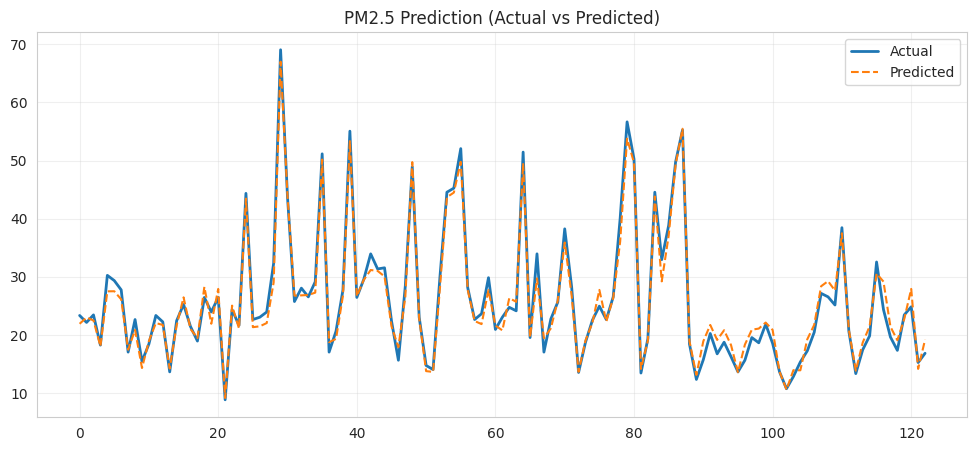

In [39]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linestyle='--')
plt.legend()
plt.title("PM2.5 Prediction (Actual vs Predicted)")
plt.grid(alpha=0.3)
plt.show()

In [40]:
print("Before tuning RMSE:", rmse)
print("After tuning RMSE:", final_rmse)
print("Improvement:", rmse - final_rmse)

Before tuning RMSE: 12.38380794372199
After tuning RMSE: 1.585130270985963
Improvement: 10.798677672736027
